In [14]:
# load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import geopandas as gpd

# load clean data — baseline feature set
CRMLSSold_cleaned = pd.read_csv('../data/cleaned_CRMLSSOLD_baseline.csv')
print(CRMLSSold_cleaned.info())
CRMLSSold_cleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 79306 entries, 0 to 79305
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CloseDate              79306 non-null  str    
 1   ClosePrice             79306 non-null  float64
 2   LivingArea             79306 non-null  float64
 3   BedroomsTotal          79306 non-null  int64  
 4   BathroomsTotalInteger  79306 non-null  int64  
 5   YearBuilt              79306 non-null  int64  
 6   GarageSpaces           76469 non-null  float64
 7   LotSizeSquareFeet      77911 non-null  float64
 8   CountyOrParish         79306 non-null  str    
 9   Latitude               79306 non-null  float64
 10  Longitude              79306 non-null  float64
 11  PoolPrivateYN          79306 non-null  str    
 12  ViewYN                 79306 non-null  str    
 13  FireplaceYN            79306 non-null  str    
 14  NewConstructionYN      79306 non-null  str    
 15  HasAssociatio

,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish,Latitude,Longitude,PoolPrivateYN,ViewYN,FireplaceYN,NewConstructionYN,HasAssociationFee
0,2025-11-30,1250000.0,1027.0,3,2,1961,2.0,5913.0,Orange,33.676050,-117.995210,False,False,False,False,False
1,2025-11-20,2299995.0,1129.0,3,1,1949,2.0,18432.0,Santa Clara,37.260693,-121.934121,Unknown,False,True,False,Unknown
2,2025-11-26,810000.0,1619.0,4,3,1978,2.0,5300.0,San Diego,32.564997,-117.064393,False,False,True,Unknown,False
3,2025-11-17,925000.0,2872.0,5,3,2000,3.0,5272.0,San Diego,32.575778,-117.024433,False,False,True,Unknown,True
4,2025-11-25,1300000.0,1727.0,3,2,1950,3.0,10500.0,San Luis Obispo,35.553064,-120.708510,False,False,True,False,False


### train/test split function (same time-based split as 03/04/05)

In [15]:
# Same time-based train/test split as 03/04/05 — test = most recent month, train = all prior months
def make_train_test_split(df, feature_cols, training_months=None):
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()

    X_train = train[feature_cols]
    y_train = train['ClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['ClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test

### Location features (PostalCode, City, DistrictName, MLSAreaMajor) — same join as 04/05

All six models will share one feature set (the richest one, from `05_advanced_models.ipynb`), so we pull in the location fields once here.

In [16]:
# Base ("old") feature/column groups — same as 03/04/05
base_feature_cols = [col for col in CRMLSSold_cleaned.columns if col != 'ClosePrice']
categorical_cols = ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN',
                    'HasAssociationFee', 'CountyOrParish']
numeric_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude']

# Pull PostalCode/City/MLSAreaMajor from the all-features CSV (row-aligned with CRMLSSold_cleaned)
_all_features_df = pd.read_csv('../data/cleaned_CRMLSSOLD_all_features.csv')
assert len(_all_features_df) == len(CRMLSSold_cleaned), "Row count mismatch between CSVs"
CRMLSSold_cleaned['PostalCode'] = _all_features_df['PostalCode'].astype(str)
CRMLSSold_cleaned['City'] = _all_features_df['City']
CRMLSSold_cleaned['MLSAreaMajor'] = _all_features_df['MLSAreaMajor']

# School district join — same approach as 04/05
districts = gpd.read_file('../data/ca_school_districts.geojson')[['DistrictName', 'geometry']]
listings = gpd.GeoDataFrame(
    CRMLSSold_cleaned,
    geometry=gpd.points_from_xy(CRMLSSold_cleaned['Longitude'], CRMLSSold_cleaned['Latitude']),
    crs='EPSG:4326'
)

n_before_join = len(listings)
listings = gpd.sjoin(listings, districts, how='left', predicate='within')
listings = listings[~listings.index.duplicated(keep='first')]
listings = listings.drop(columns=['geometry', 'index_right'])
assert len(listings) == n_before_join, "Row count changed after dedup — join still producing extras"

n_unmatched = listings['DistrictName'].isna().sum()
print(f"Unmatched to a district: {n_unmatched:,} ({n_unmatched / len(listings):.2%})")
listings = listings.dropna(subset=['DistrictName'])

CRMLSSold_cleaned = pd.DataFrame(listings)

# Keep ClosePrice in dollars for MAPE/MdAPE later; log-transform into a
# separate column for model fitting/R^2 (comparable to 03/04/05, which log-transformed in place)
CRMLSSold_cleaned['ClosePriceDollars'] = CRMLSSold_cleaned['ClosePrice']
CRMLSSold_cleaned['ClosePrice'] = np.log(CRMLSSold_cleaned['ClosePrice'])

print(f"Unique PostalCode: {CRMLSSold_cleaned['PostalCode'].nunique():,}")
print(f"Unique City: {CRMLSSold_cleaned['City'].nunique():,}")
print(f"Unique DistrictName: {CRMLSSold_cleaned['DistrictName'].nunique():,}")
print(f"Unique MLSAreaMajor: {CRMLSSold_cleaned['MLSAreaMajor'].nunique():,}")

Unmatched to a district: 5 (0.01%)
Unique PostalCode: 1,295
Unique City: 880
Unique DistrictName: 545
Unique MLSAreaMajor: 963


### Feature set & preprocessor — same feature set for every model

All six models use the same feature set for a like-for-like comparison: base features + `PostalCode`/`City`/`DistrictName`/`MLSAreaMajor` — the richest feature set from `05_advanced_models.ipynb` (used there for XGBoost/LightGBM/CatBoost).

In [17]:
# Shared feature set: base features + PostalCode/City/DistrictName/MLSAreaMajor
location_cols = ['PostalCode', 'City', 'DistrictName', 'MLSAreaMajor']
feature_cols = base_feature_cols + location_cols

preprocessor = ColumnTransformer([
    ('impute', SimpleImputer(strategy='median'), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('encode_location', OneHotEncoder(handle_unknown='ignore', min_frequency=50), location_cols),
])

X_train, y_train, X_test, y_test = make_train_test_split(
    CRMLSSold_cleaned, feature_cols, training_months=None
)
# dollar-scale targets for MAPE/MdAPE (ClosePrice above is log-transformed)
y_train_dollars = CRMLSSold_cleaned.loc[X_train.index, 'ClosePriceDollars']
y_test_dollars = CRMLSSold_cleaned.loc[X_test.index, 'ClosePriceDollars']

Test month:  2026-06
Train range: 2025-11 to 2026-05  (7 months)
X_train: (67174, 19)  |  X_test: (12127, 19)


### Models with their best parameters from 04/05

- `LinearRegression` — no hyperparameters
- `DecisionTree` / `RandomForest` — fixed params from `04_model_comparison.ipynb`
- `XGBoost` / `LightGBM` / `CatBoost` — grid-search winners from `05_advanced_models.ipynb` (`n_estimators`/`iterations`=1000, `learning_rate`=0.1, `max_depth`/`depth`=8)

In [18]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42, max_depth=12, min_samples_leaf=10),
    'RandomForest': RandomForestRegressor(random_state=42, max_depth=16, min_samples_leaf=5, n_estimators=200),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=1000, learning_rate=0.1, max_depth=8),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_estimators=1000, learning_rate=0.1, max_depth=8),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=False, iterations=1000, learning_rate=0.1, depth=8),
}

### Fit each model and compute R^2, MAPE, MdAPE

Every model was trained on `log(ClosePrice)`, so R^2 is reported in log-price space (comparable to 03/04/05). Predictions are converted back to dollars (`np.exp`) before computing MAPE/MdAPE against the true `ClosePrice` in dollars.

Metrics are computed on both train and test sets so we can check the train/test gap for overfitting — a large gap (high train R^2, much lower test R^2) means the model is memorizing training data rather than generalizing.

In [19]:
def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))

# Test-set dollar-scale predictions per model, kept around for the price-band breakdown below
test_preds_dollars = {}

eval_results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    preds_log_train = pipeline.predict(X_train)
    preds_log_test = pipeline.predict(X_test)

    r2_train = r2_score(y_train, preds_log_train)
    r2_test = r2_score(y_test, preds_log_test)

    preds_dollars_train = np.exp(preds_log_train)
    preds_dollars_test = np.exp(preds_log_test)
    test_preds_dollars[name] = preds_dollars_test

    mape_train = mean_absolute_percentage_error(y_train_dollars, preds_dollars_train)
    mape_test = mean_absolute_percentage_error(y_test_dollars, preds_dollars_test)

    mdape_train = median_absolute_percentage_error(y_train_dollars, preds_dollars_train)
    mdape_test = median_absolute_percentage_error(y_test_dollars, preds_dollars_test)

    mae_dollars_train = mean_absolute_error(y_train_dollars, preds_dollars_train)
    mae_dollars_test = mean_absolute_error(y_test_dollars, preds_dollars_test)

    rmse_dollars_train = mean_squared_error(y_train_dollars, preds_dollars_train) ** 0.5
    rmse_dollars_test = mean_squared_error(y_test_dollars, preds_dollars_test) ** 0.5

    eval_results[name] = {
        'R^2': r2_test, 'MAPE': mape_test, 'MdAPE': mdape_test, 'MAE ($)': mae_dollars_test, 'RMSE ($)': rmse_dollars_test,
        'R^2 (train)': r2_train, 'MAPE (train)': mape_train, 'MdAPE (train)': mdape_train,
        'MAE (train, $)': mae_dollars_train, 'RMSE (train, $)': rmse_dollars_train,
        'R^2 gap': r2_train - r2_test, 'MAPE gap': mape_test - mape_train, 'MdAPE gap': mdape_test - mdape_train,
    }
    print(f"{name}")
    print(f"  R^2:    test {r2_test:.4f}  |  train {r2_train:.4f}  |  gap {r2_train - r2_test:.4f}")
    print(f"  MAPE:   test {mape_test:.2%}  |  train {mape_train:.2%}  |  gap {mape_test - mape_train:.2%}")
    print(f"  MdAPE:  test {mdape_test:.2%}  |  train {mdape_train:.2%}  |  gap {mdape_test - mdape_train:.2%}")
    print(f"  MAE:    test ${mae_dollars_test:,.0f}  |  train ${mae_dollars_train:,.0f}")
    print(f"  RMSE:   test ${rmse_dollars_test:,.0f}  |  train ${rmse_dollars_train:,.0f}\n")

LinearRegression
  R^2:    test 0.8528  |  train 0.8502  |  gap -0.0026
  MAPE:   test 17.04%  |  train 17.23%  |  gap -0.19%
  MdAPE:  test 12.76%  |  train 12.69%  |  gap 0.07%
  MAE:    test $224,150  |  train $217,618
  RMSE:   test $420,609  |  train $406,612

DecisionTree
  R^2:    test 0.8432  |  train 0.8639  |  gap 0.0207
  MAPE:   test 17.18%  |  train 16.01%  |  gap 1.17%
  MdAPE:  test 11.54%  |  train 10.97%  |  gap 0.58%
  MAE:    test $231,705  |  train $206,247
  RMSE:   test $434,679  |  train $383,433

RandomForest
  R^2:    test 0.9112  |  train 0.9432  |  gap 0.0320
  MAPE:   test 12.69%  |  train 10.10%  |  gap 2.58%
  MdAPE:  test 8.63%  |  train 6.91%  |  gap 1.72%
  MAE:    test $173,184  |  train $131,584
  RMSE:   test $340,559  |  train $258,059

XGBoost
  R^2:    test 0.9323  |  train 0.9696  |  gap 0.0373
  MAPE:   test 11.23%  |  train 7.58%  |  gap 3.65%
  MdAPE:  test 7.96%  |  train 5.41%  |  gap 2.55%
  MAE:    test $150,360  |  train $91,444
  RMSE:  

### LightGBM & CatBoost with native categorical handling

The comparison above one-hot encodes every model equally for a fair baseline. But LightGBM and CatBoost both have native categorical support that's usually a better fit than one-hot encoding.

Here we refit  those two models on the raw (unencoded) categorical columns, letting each library handle categories its own way, to see if it beats their one-hot results above.

In [20]:
# Raw (unencoded) categorical columns — restrict to the columns the one-hot preprocessor
# actually used (numeric_cols + all_cat_cols). feature_cols also carries CloseDate, which the
# ColumnTransformer silently dropped for the other six models but would break a raw .fit() here.
all_cat_cols = categorical_cols + location_cols
native_feature_cols = numeric_cols + all_cat_cols

X_train_native = X_train[native_feature_cols].copy()
X_test_native = X_test[native_feature_cols].copy()
for col in all_cat_cols:
    # CatBoost's cat_features can't hold NaN, so route true missing values AND categories
    # unseen in train (e.g. a test-only PostalCode) into the same explicit 'Unknown' bucket
    # used throughout 02_preprocessing.ipynb for other categorical columns.
    train_values = X_train_native[col].astype(str).where(X_train_native[col].notna(), 'Unknown')
    train_categories = pd.Index(train_values.unique())
    if 'Unknown' not in train_categories:
        train_categories = train_categories.insert(0, 'Unknown')

    test_values = X_test_native[col].astype(str).where(X_test_native[col].notna(), 'Unknown')
    test_values = test_values.where(test_values.isin(train_categories), 'Unknown')

    X_train_native[col] = pd.Categorical(train_values, categories=train_categories)
    X_test_native[col] = pd.Categorical(test_values, categories=train_categories)

native_models = {
    'LightGBM (native cat)': LGBMRegressor(random_state=42, verbose=-1, n_estimators=1000, learning_rate=0.1, max_depth=8),
    'CatBoost (native cat)': CatBoostRegressor(random_state=42, verbose=False, iterations=1000, learning_rate=0.1, depth=8,
                                                cat_features=all_cat_cols),
}

for name, model in native_models.items():
    model.fit(X_train_native, y_train)

    preds_log_train = model.predict(X_train_native)
    preds_log_test = model.predict(X_test_native)

    r2_train = r2_score(y_train, preds_log_train)
    r2_test = r2_score(y_test, preds_log_test)

    preds_dollars_train = np.exp(preds_log_train)
    preds_dollars_test = np.exp(preds_log_test)
    test_preds_dollars[name] = preds_dollars_test

    mape_train = mean_absolute_percentage_error(y_train_dollars, preds_dollars_train)
    mape_test = mean_absolute_percentage_error(y_test_dollars, preds_dollars_test)

    mdape_train = median_absolute_percentage_error(y_train_dollars, preds_dollars_train)
    mdape_test = median_absolute_percentage_error(y_test_dollars, preds_dollars_test)

    mae_dollars_train = mean_absolute_error(y_train_dollars, preds_dollars_train)
    mae_dollars_test = mean_absolute_error(y_test_dollars, preds_dollars_test)

    rmse_dollars_train = mean_squared_error(y_train_dollars, preds_dollars_train) ** 0.5
    rmse_dollars_test = mean_squared_error(y_test_dollars, preds_dollars_test) ** 0.5

    eval_results[name] = {
        'R^2': r2_test, 'MAPE': mape_test, 'MdAPE': mdape_test, 'MAE ($)': mae_dollars_test, 'RMSE ($)': rmse_dollars_test,
        'R^2 (train)': r2_train, 'MAPE (train)': mape_train, 'MdAPE (train)': mdape_train,
        'MAE (train, $)': mae_dollars_train, 'RMSE (train, $)': rmse_dollars_train,
        'R^2 gap': r2_train - r2_test, 'MAPE gap': mape_test - mape_train, 'MdAPE gap': mdape_test - mdape_train,
    }
    print(f"{name}")
    print(f"  R^2:    test {r2_test:.4f}  |  train {r2_train:.4f}  |  gap {r2_train - r2_test:.4f}")
    print(f"  MAPE:   test {mape_test:.2%}  |  train {mape_train:.2%}  |  gap {mape_test - mape_train:.2%}")
    print(f"  MdAPE:  test {mdape_test:.2%}  |  train {mdape_train:.2%}  |  gap {mdape_test - mdape_train:.2%}")
    print(f"  MAE:    test ${mae_dollars_test:,.0f}  |  train ${mae_dollars_train:,.0f}")
    print(f"  RMSE:   test ${rmse_dollars_test:,.0f}  |  train ${rmse_dollars_train:,.0f}\n")

LightGBM (native cat)
  R^2:    test 0.9359  |  train 0.9695  |  gap 0.0336
  MAPE:   test 10.91%  |  train 7.70%  |  gap 3.21%
  MdAPE:  test 7.61%  |  train 5.65%  |  gap 1.96%
  MAE:    test $145,355  |  train $93,792
  RMSE:   test $280,659  |  train $166,129

CatBoost (native cat)
  R^2:    test 0.9351  |  train 0.9499  |  gap 0.0148
  MAPE:   test 11.02%  |  train 9.86%  |  gap 1.17%
  MdAPE:  test 7.70%  |  train 7.10%  |  gap 0.60%
  MAE:    test $147,746  |  train $125,102
  RMSE:   test $285,349  |  train $230,638



### Full comparison table (one-hot baseline + native-categorical LightGBM/CatBoost)

In [21]:
column_order = ['R^2', 'R^2 (train)', 'R^2 gap', 'MAPE', 'MAPE (train)', 'MAPE gap',
                 'MdAPE', 'MdAPE (train)', 'MdAPE gap', 'MAE ($)', 'MAE (train, $)', 'RMSE ($)', 'RMSE (train, $)']
full_comparison_table = pd.DataFrame(eval_results).T.sort_values('R^2', ascending=False)

display_table = full_comparison_table[column_order].copy()
display_table[['R^2', 'R^2 (train)', 'R^2 gap']] = display_table[['R^2', 'R^2 (train)', 'R^2 gap']].round(4)
for col in ['MAPE', 'MAPE (train)', 'MAPE gap', 'MdAPE', 'MdAPE (train)', 'MdAPE gap']:
    display_table[col] = full_comparison_table[col].map('{:.2%}'.format)
for col in ['MAE ($)', 'MAE (train, $)', 'RMSE ($)', 'RMSE (train, $)']:
    display_table[col] = full_comparison_table[col].map('{:,.2f}'.format)
display_table

,R^2,R^2 (train),R^2 gap,MAPE,MAPE (train),MAPE gap,MdAPE,MdAPE (train),MdAPE gap,MAE ($),"MAE (train, $)",RMSE ($),"RMSE (train, $)"
LightGBM (native cat),0.9359,0.9695,0.0336,10.91%,7.70%,3.21%,7.61%,5.65%,1.96%,"145,355.34","93,791.87","280,659.16","166,129.02"
CatBoost (native cat),0.9351,0.9499,0.0148,11.02%,9.86%,1.17%,7.70%,7.10%,0.60%,"147,746.10","125,102.42","285,349.40","230,638.16"
CatBoost,0.9335,0.9455,0.0120,11.24%,10.36%,0.88%,8.04%,7.53%,0.52%,"149,841.13","130,350.52","285,479.91","237,547.06"
LightGBM,0.9333,0.9499,0.0166,11.24%,9.78%,1.46%,7.99%,6.99%,1.00%,"148,964.69","122,822.05","283,379.61","227,422.90"
XGBoost,0.9323,0.9696,0.0373,11.23%,7.58%,3.65%,7.96%,5.41%,2.55%,"150,360.33","91,444.14","288,908.05","165,556.40"
RandomForest,0.9112,0.9432,0.0320,12.69%,10.10%,2.58%,8.63%,6.91%,1.72%,"173,183.75","131,584.03","340,558.89","258,058.86"
LinearRegression,0.8528,0.8502,-0.0026,17.04%,17.23%,-0.19%,12.76%,12.69%,0.07%,"224,150.14","217,618.05","420,609.45","406,612.39"
DecisionTree,0.8432,0.8639,0.0207,17.18%,16.01%,1.17%,11.54%,10.97%,0.58%,"231,705.20","206,246.86","434,679.27","383,432.73"


In [22]:
full_comparison_table.to_csv('../metric_summary/metrics_summary.csv')

### Performance by price band



In [23]:
price_band_edges = [0, 500_000, 1_000_000, 2_000_000, 5_000_000, np.inf]
price_band_labels = ['Under $500K', '$500K-$1M', '$1M-$2M', '$2M-$5M', 'Over $5M']

price_bands = pd.cut(y_test_dollars, bins=price_band_edges, labels=price_band_labels)

band_rows = []
for name, preds_dollars_test in test_preds_dollars.items():
    preds_dollars_test = pd.Series(preds_dollars_test, index=y_test_dollars.index)
    for band in price_band_labels:
        mask = price_bands == band
        n = mask.sum()
        if n == 0:
            continue
        y_true_band = y_test_dollars[mask]
        y_pred_band = preds_dollars_test[mask]

        band_rows.append({
            'Model': name,
            'Price band': band,
            'n': n,
            'R^2': r2_score(y_true_band, y_pred_band),
            'MAPE': mean_absolute_percentage_error(y_true_band, y_pred_band),
            'MdAPE': median_absolute_percentage_error(y_true_band, y_pred_band),
            'MAE ($)': mean_absolute_error(y_true_band, y_pred_band),
            'RMSE ($)': mean_squared_error(y_true_band, y_pred_band) ** 0.5,
        })

price_band_table = pd.DataFrame(band_rows).set_index(['Model', 'Price band']).loc[full_comparison_table.index]

price_band_display = price_band_table.copy()
price_band_display['R^2'] = price_band_display['R^2'].round(4)
price_band_display['MAPE'] = price_band_table['MAPE'].map('{:.2%}'.format)
price_band_display['MdAPE'] = price_band_table['MdAPE'].map('{:.2%}'.format)
price_band_display['MAE ($)'] = price_band_table['MAE ($)'].map('{:,.2f}'.format)
price_band_display['RMSE ($)'] = price_band_table['RMSE ($)'].map('{:,.2f}'.format)
price_band_display

n      R^2    MAPE   MdAPE  \
Model                 Price band                                   
LightGBM (native cat) Under $500K  1615  -0.0572  11.73%   7.21%   
                      $500K-$1M    5168   0.4583   9.01%   6.10%   
                      $1M-$2M      3841   0.2845  11.56%   8.85%   
                      $2M-$5M      1423   0.3005  14.41%  11.61%   
                      Over $5M       80 -14.9925  23.50%  21.66%   
CatBoost (native cat) Under $500K  1615  -0.1599  12.10%   7.30%   
                      $500K-$1M    5168   0.4718   9.06%   6.21%   
                      $1M-$2M      3841   0.2948  11.58%   8.98%   
                      $2M-$5M      1423   0.2884  14.60%  12.21%   
                      Over $5M       80 -17.1216  26.06%  24.46%   
CatBoost              Under $500K  1615  -0.1798  12.41%   7.45%   
                      $500K-$1M    5168   0.4608   9.33%   6.48%   
                      $1M-$2M      3841   0.3013  11.68%   9.24%   
                      $2M-$5M      1423   0.2789  14.93%  12.96%   
                      Over $5M       80 -16.7253  24.97%  25.62%   
LightGBM              Under $500K  1615  -0.2494  12.51%   7.50%   
                      $500K-$1M    5168   0.4431   9.31%   6.44%   
                      $1M-$2M      3841   0.2776  11.76%   9.32%   
                      $2M-$5M      1423   0.2946  14.68%  12.23%   
                      Over $5M       80 -15.7476  24.11%  21.72%   
XGBoost               Under $500K  1615  -0.2419  12.46%   7.69%   
                      $500K-$1M    5168   0.4625   9.09%   6.19%   
                      $1M-$2M      3841   0.2494  11.90%   9.43%   
                      $2M-$5M      1423   0.2743  14.93%  12.07%   
                      Over $5M       80 -17.1806  26.15%  26.82%   
RandomForest          Under $500K  1615  -0.7242  13.73%   7.79%   
                      $500K-$1M    5168   0.2185  10.30%   6.66%   
                      $1M-$2M      3841   0.0916  13.24%  10.24%   
                      $2M-$5M      1423  -0.0099  17.45%  15.03%   
                      Over $5M       80 -26.8430  34.51%  33.04%   
LinearRegression      Under $500K  1615  -2.1962  20.61%  13.68%   
                      $500K-$1M    5168  -0.2018  15.02%  11.17%   
                      $1M-$2M      3841  -0.2182  15.41%  12.12%   
                      $2M-$5M      1423  -0.6680  23.53%  21.05%   
                      Over $5M       80 -37.8229  38.63%  39.82%   
DecisionTree          Under $500K  1615  -2.3299  17.62%   9.94%   
                      $500K-$1M    5168  -0.5870  14.28%   9.19%   
                      $1M-$2M      3841  -0.7258  17.99%  13.75%   
                      $2M-$5M      1423  -0.6917  23.87%  21.25%   
                      Over $5M       80 -33.6655  37.63%  36.77%   

                                        MAE ($)      RMSE ($)  
Model                 Price band                               
LightGBM (native cat) Under $500K     44,893.35     69,184.05  
                      $500K-$1M       68,037.04    103,563.71  
                      $1M-$2M        164,293.39    228,638.03  
                      $2M-$5M        421,880.77    584,439.80  
                      Over $5M     1,340,234.44  1,601,701.43  
CatBoost (native cat) Under $500K     46,230.36     72,466.31  
                      $500K-$1M       68,281.57    102,268.79  
                      $1M-$2M        164,342.88    226,979.30  
                      $2M-$5M        431,400.99    589,468.59  
                      Over $5M     1,488,140.14  1,704,987.13  
CatBoost              Under $500K     47,327.08     73,086.92  
                      $500K-$1M       70,307.38    103,324.85  
                      $1M-$2M        165,795.27    225,928.66  
                      $2M-$5M        440,270.96    593,359.29  
                      Over $5M     1,425,204.78  1,686,242.04  
LightGBM              Under $500K     47,710.03     75,209.40  
                      $500K-$

### Best / worst model per price band

Ranked by RMSE ($) within each band.

| Price band | Best model | Best RMSE ($) | Best MAPE | Worst model | Worst RMSE ($) | Worst MAPE |
|---|---|---|---|---|---|---|
| Under $500K | LightGBM (native cat) | $69,184 | 0.1173 | DecisionTree | $122,785 | 0.1762 |
| $500K-$1M | CatBoost (native cat) | $102,269 | 0.0906 | DecisionTree | $177,260 | 0.1428 |
| $1M-$2M | CatBoost | $225,929 | 0.1168 | DecisionTree | $355,090 | 0.1799 |
| $2M-$5M | LightGBM (native cat) | $584,440 | 0.1441 | DecisionTree | $908,861 | 0.2387 |
| Over $5M | LightGBM (native cat) | $1,601,701 | 0.2350 | LinearRegression | $2,495,553 | 0.3863 |

LightGBM (native cat) is the nearly the best model for the cheaper and expensive bans(below $500k and above $2m) where as catboost performed better for the most frequent listing prices($500k-$2m) bands , with gradient boost performing better than the other types of models. Where as the DecisionTree/LinearRegression are consistently worst compared to the boosted models.

### Price-band comparison plot

Grouped bar charts of MAPE and RMSE ($) by price band, one bar per model, so the table above is easier to scan visually.

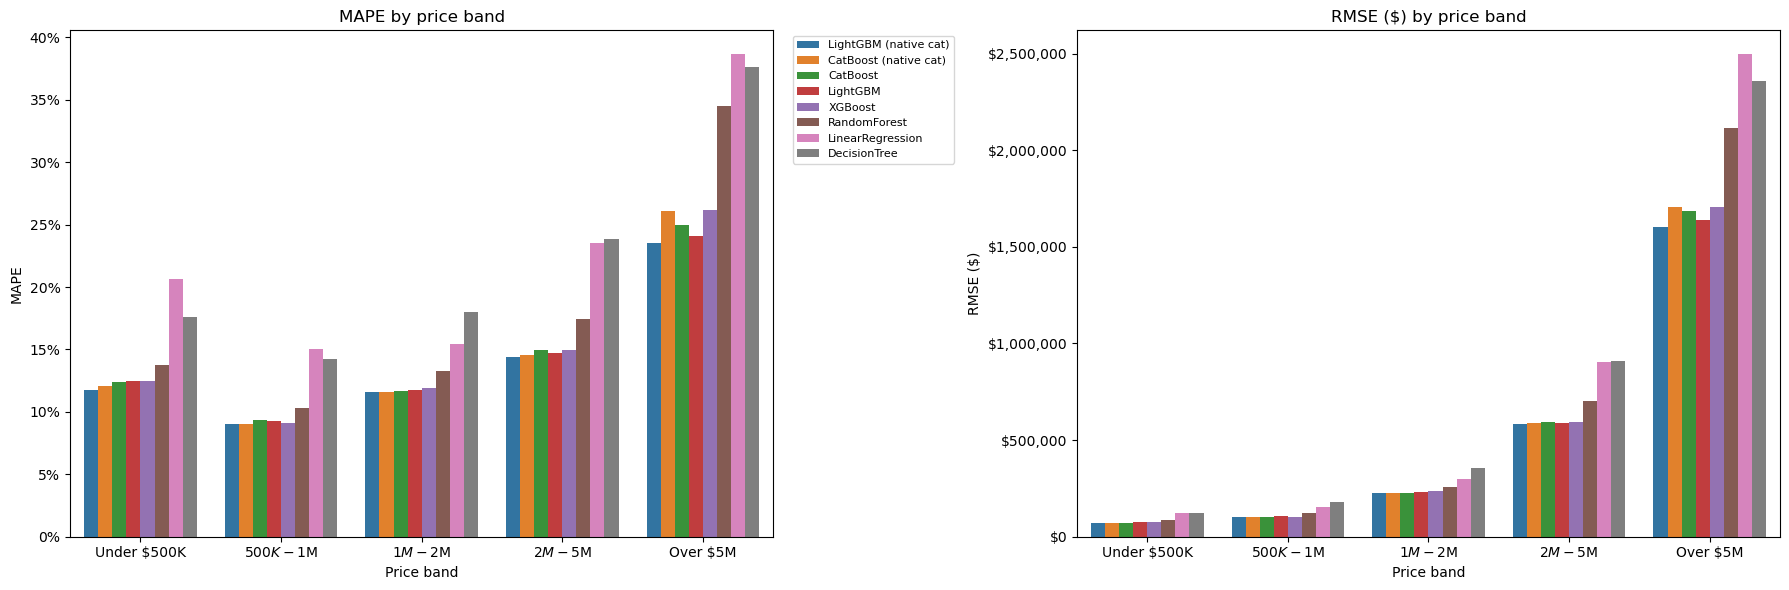

In [24]:
plot_data = price_band_table.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=plot_data, x='Price band', y='MAPE', hue='Model', order=price_band_labels, ax=axes[0])
axes[0].set_title('MAPE by price band')
axes[0].set_ylabel('MAPE')
axes[0].yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

sns.barplot(data=plot_data, x='Price band', y='RMSE ($)', hue='Model', order=price_band_labels, ax=axes[1])
axes[1].set_title('RMSE ($) by price band')
axes[1].set_ylabel('RMSE ($)')
axes[1].yaxis.set_major_formatter(lambda y, _: f'${y:,.0f}')
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

### CatBoost is the best model as it performed the best on the most frequent price bands in the test($500k-$2m makes up ~74% of the test set)

### Save the CatBoost pipeline for deployment

Persists the fitted `CatBoost` pipeline (preprocessor + model, one-hot encoded — `pipeline` still holds this from the last iteration of the model-comparison loop above) plus the metadata `app.py` needs to build its input form: feature lists, dropdown choices for each categorical column, and numeric ranges/medians for sensible defaults.

In [25]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(pipeline, '../models/catboost_price_model.pkl')

feature_choices = {
    col: sorted(CRMLSSold_cleaned[col].dropna().astype(str).unique().tolist())
    for col in categorical_cols + location_cols
}

numeric_ranges = {
    col: {
        'min': float(CRMLSSold_cleaned[col].min()),
        'max': float(CRMLSSold_cleaned[col].max()),
        'median': float(CRMLSSold_cleaned[col].median()),
    }
    for col in numeric_cols
}

model_metadata = {
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'location_cols': location_cols,
    'feature_choices': feature_choices,
    'numeric_ranges': numeric_ranges,
    'log_target': True,
    'test_r2': float(full_comparison_table.loc['CatBoost', 'R^2']),
    'test_mae': float(full_comparison_table.loc['CatBoost', 'MAE ($)']),
    'test_mape': float(full_comparison_table.loc['CatBoost', 'MAPE']),
}
joblib.dump(model_metadata, '../models/catboost_price_model_metadata.pkl')

print("Saved CatBoost pipeline  -> ../models/catboost_price_model.pkl")
print("Saved metadata           -> ../models/catboost_price_model_metadata.pkl")

Saved CatBoost pipeline  -> ../models/catboost_price_model.pkl
Saved metadata           -> ../models/catboost_price_model_metadata.pkl
